In [55]:
import os
import sys
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import loadtxt
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import SGDClassifier


str-c197


In [48]:
dataset_druggable = pd.read_csv("input/combined_DepMap_21Q3_druggable.csv")

In [41]:
dataset_ccle = pd.read_csv("input/combined_DepMap_21Q3_CCLE_expression.csv")

In [73]:
dataset_druggable_X = dataset_druggable.iloc[:, 1:-4686]
drug_y_druggable = dataset_druggable.iloc[:, -4686:]
dataset_ccle_X = dataset_ccle.iloc[:, 1:-4686]
drug_y_ccle = dataset_ccle.iloc[:, -4686:]

In [72]:
dataset_druggable_X

,cell_line_name,ABAT,ABCA1,ABCB1,ABCB11,ABCB4,ABCC1,ABCC2,ABCC4,ABCC5,...,U2AF2,UBA1,UPF1,UTP20,VARS,VPS25,WDR74,WDR75,YARS,YARS2
0,786O,0.194760,-0.26739,0.011616,-0.103940,-0.092660,0.111730,-0.071859,0.195760,0.271500,...,-1.07160,-1.68470,-0.78354,-0.98203,-1.42700,-2.08370,-1.35380,-1.04150,-1.58640,-1.25660
1,786O,-0.103230,-0.40562,-0.206630,-0.001647,0.006967,-0.071111,0.120320,0.124950,0.104780,...,-1.06710,-1.73460,-0.90807,-1.19160,-0.99568,-2.32440,-1.41330,-1.11150,-1.54610,-1.71090
2,786O,0.055868,-0.23192,-0.178830,0.133800,-0.012069,-0.022218,-0.087652,0.104110,0.165020,...,-1.51480,-1.90400,-0.83737,-0.90659,-1.28590,-1.53110,-1.46060,-0.96340,-1.41860,-1.44360
3,A2780,-0.050991,-0.11465,0.046887,0.300450,0.166470,-0.062285,-0.002715,0.007512,0.110650,...,-1.57140,-1.94750,-1.18270,-1.34970,-1.59350,-1.93990,-1.34580,-1.62680,-1.85570,-1.99660
4,A2780,-0.013918,-0.10453,-0.119910,-0.003147,-0.049564,-0.033798,0.061329,0.046242,0.124910,...,-1.96970,-1.82520,-1.51090,-1.57020,-1.89410,-2.52830,-1.98590,-1.26140,-2.69070,-2.18330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,CORL105,0.095641,-0.11959,-0.028820,0.050700,-0.006511,0.117290,-0.012792,0.190790,0.061830,...,-0.67827,-0.65626,-0.51908,-0.51685,-0.63570,-0.60149,-0.53589,-0.57855,-0.59471,-0.51954
920,T47D,-0.105470,-0.10929,-0.117870,0.044214,0.048929,-0.022116,-0.171560,0.116700,-0.215390,...,-1.05250,-1.42960,-0.65785,-0.80932,-0.99327,-1.46430,-0.77454,-0.87114,-1.25930,-2.41030
921,T47D,-0.220170,-0.14524,-0.164060,0.099162,0.098817,0.047755,-0.121520,0.030962,-0.230970,...,-0.96895,-1.22480,-0.58564,-1.02550,-0.62092,-1.56610,-0.75895,-1.07840,-1.25520,-2.20120
922,PANC0504,-0.431960,0.10414,-0.222460,0.016867,0.319490,-0.033414,-0.010346,0.106650,0.029121,...,-0.27244,-0.97848,-0.10001,-0.43307,-0.29409,-1.12250,-0.62699,-0.34030,-0.43745,-0.96375


In [19]:
dataset = pd.read_csv("input/combined_DepMap_21Q3.csv")
num_gene = 17651
drug_X = dataset.iloc[:, 1:num_gene+1]
drug_y_all = dataset.iloc[:, -4686:]
drug_list = drug_y_all.columns.tolist()

In [ ]:
directory_path = "output/oversample"
os.makedirs({outdir}, exist_ok=True)

In [13]:
ROS = RandomOverSampler(random_state=72)
X_ovs, y_ovs = ROS.fit_resample(X, drug_y_all['BRD-A00100033-001-08-9::2.5::HTS'])

In [92]:
set(dataset_druggable_X.keys()).intersection(drug_X.keys())

{'GJB4',
 'PRKACA',
 'SCN11A',
 'CD4',
 'APEH',
 'CASR',
 'MMP1',
 'CASP9',
 'STAT3',
 'NOTCH4',
 'IRAK1',
 'TUBB4B',
 'HMGCR',
 'GRIN2A',
 'NDC80',
 'OXSR1',
 'CXCR3',
 'NOD1',
 'PSMB6',
 'MMP13',
 'SCNN1A',
 'PSMD1',
 'PSMD8',
 'TRPV1',
 'CACNA1B',
 'LPAR4',
 'YES1',
 'MAPKAP1',
 'AVPR1B',
 'DCPS',
 'F11',
 'DPP7',
 'FER',
 'KLK6',
 'PLK4',
 'TUBG1',
 'ADRA2C',
 'ANGPT2',
 'THOC5',
 'NDUFC1',
 'CDK3',
 'EIF2AK1',
 'CDK4',
 'KCNA5',
 'PPARD',
 'CLEC4C',
 'DYRK1A',
 'TGM2',
 'CDK9',
 'PTGER1',
 'FGR',
 'ATP6AP1',
 'GSTP1',
 'SRD5A1',
 'P2RY6',
 'CSNK2A1',
 'CCR5',
 'AGTR2',
 'PTPRG',
 'DHODH',
 'SNCA',
 'PTPRF',
 'STK24',
 'BRD3',
 'DGAT1',
 'NDUFA2',
 'SIRT6',
 'TNFRSF4',
 'SMO',
 'PKN3',
 'GJD3',
 'BUB1',
 'ATP1A4',
 'ECE1',
 'GRK4',
 'PSMD12',
 'MMP2',
 'WDR5',
 'ABCC5',
 'MAPK12',
 'SLC16A7',
 'PRKG2',
 'TMPRSS6',
 'TEC',
 'TAOK3',
 'RPL37A',
 'SSTR5',
 'ULK3',
 'SCN9A',
 'CTSE',
 'KCNA1',
 'TRPV3',
 'EPHA7',
 'CACNA1H',
 'PHKG2',
 'HSPA5',
 'SELL',
 'GRIN3A',
 'RPL35',
 'S1PR2',
 

In [95]:
sum(np.sum(drug_X[dataset_druggable_X.keys()] - dataset_druggable_X))

/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


0.0

In [ ]:
drug_X_combined = pd.concat([drug_X, dataset_druggable_X])

/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


0

In [82]:
drug_y_all

,BRD-A00077618-236-07-6::2.5::HTS,BRD-A00100033-001-08-9::2.5::HTS,BRD-A00147595-001-01-5::2.5::HTS,BRD-A00218260-001-03-4::2.5::HTS,BRD-A00376169-001-01-6::2.5::HTS,BRD-A00520476-001-07-4::2.5::HTS,BRD-A00546892-001-02-6::2.5::HTS,BRD-A00578795-001-04-3::2.5::HTS,BRD-A00758722-001-04-9::2.5::HTS,BRD-A00827783-001-24-6::2.5::HTS,...,BRD-K98557884-001-01-6::2.5::MTS004,BRD-K99077012-001-01-9::2.332734192::MTS004,BRD-K99199077-001-16-1::2.603211317::MTS004,BRD-K99431849-001-01-7::2.500018158::MTS004,BRD-K99447003-335-04-1::2.37737659::MTS004,BRD-K99506538-001-03-8::2.5::MTS004,BRD-K99616396-001-05-1::2.499991421::MTS004,BRD-K99879819-001-02-1::2.5187366::MTS004,BRD-K99919177-001-01-3::2.5::MTS004,BRD-M63173034-001-03-6::2.64076472::MTS004
0,1,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,1
1,1,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,1
3,1,0,0,1,0,0,0,1,1,1,...,0,0,0,0,1,0,0,0,1,0
4,1,0,0,1,0,0,0,1,1,1,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,0,1,0,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
920,0,0,0,1,0,0,0,1,0,1,...,0,1,0,1,0,1,0,0,0,0
921,0,0,0,1,0,0,0,1,0,1,...,0,1,0,1,0,1,0,0,0,0
922,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0


In [7]:
a = XGBClassifier

In [ ]:
{XGBClassifier:'XGBClassifier',
				   RandomForestClassifier:'RandomForestClassifier'
				   }[a]

'XGBClassifier'

In [109]:

GRID_SEARCH_PARAM = {
'XGB': {
		"n_estimators": [100, 150, 250],
		"max_depth" : [20, 50, 100, 200],
 },
 'RF':{
	 "n_estimators": [100, 150, 250],
	 "max_depth" : [20, 50, 100, 200],
 },
 'SGD':{
	 'l1_ratio':[0.2, 0.15, 0.1, 0.05],
	 'alpha':[0.02, 0.05]
 }
}

# Basic function to handel sklearn and traditional model training and basic hpo
# TODO refactor this into a class maybe, class DrugModel
def skl_drug_model(X, Y, drug, model = XGBClassifier, oversample = True, fixed_params={}, search_params = {}, search_method = 'gridcv'):

	assert model in [XGBClassifier, RandomForestClassifier, SGDClassifier], f' {model} type not supported'

	
	y = Y[drug]

	 # split X and y into training and testing sets
	X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)


	if oversample:
		ros = SMOTE(random_state=72)
		X_res, y_res = ros.fit_resample(X_train, y_train)
		oversample = 'oversample'
	else:
		X_res, y_res = X_train, y_train
		oversample = ''


	 # instantiate the classifier
	 

	# k-fold cross validation using multiple metric evaluation
	kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
	 #cv_results = cross_validate(xgbc, X_train, y_train, cv=kfold, scoring= ['accuracy', 'precision', 'recall', 'f1'], n_jobs = 10)
	if oversample:
		imba_pipeline = Pipeline([('sampling', SMOTE(random_state=72)), 
							  ('classifier', model(n_jobs=20, **fixed_params))])
		grid_search_parameters = {'classifier__' + key: search_params[key] for key in search_params}
	else:
		imba_pipeline = model(**fixed_params, n_jobs=20)
	 #cross_val_score(imba_pipeline, X_train, y_train, scoring='recall', cv=kf)
	model0 = model(**fixed_params, n_jobs=20)

	 #perform gridsearch if needed
	if search_method == 'gridcv' and search_params:
		grid_imba = GridSearchCV(imba_pipeline, param_grid=grid_search_parameters, cv=kfold, scoring='precision',
						return_train_score=True)
		grid_imba.fit(X_train, y_train) 

		best_params = {key.removeprefix('classifier__'):grid_imba.best_params_[key] for key in grid_imba.best_params_}
		print(best_params)
		model0.set_params(**best_params)
	 
	 
	if oversample:
		imba_pipeline = Pipeline([('sampling', RandomOverSampler(random_state=72)), 
							  ('classifier', model0)])
	else:
		imba_pipeline = model0
		  
	#generate cross validation results of best model with correct oversampling 
	cv_results = cross_validate(imba_pipeline, X_train, y_train, cv=kfold, scoring= ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], n_jobs = 20)
	cv_results = pd.DataFrame(cv_results)
	

	 # declare parameters
	 

	 # fit the classifier to the training data
	model0.fit(X_res, y_res)

	 # save the trained model
	
		  
	final_results = {
		'best_model': model0,
		'drug': drug,
		'model_class': model,
		'model_search': grid_imba,
		'search_method': search_method,
		'X_test': X_test,
		'Y_test': y_test,
		'X_train': X_train,
		'Y_train': y_train,
		'cv_results':cv_results,
		'oversample': True if oversample else False
	}

	return final_results


def write_drug_model_result(model_results, out_dir):
	 
	model0 = model_results['best_model']
	oversample = 'oversample' if model_results['oversample'] else ''
	drug = model_results['drug']
	model_class = model_results['model_class']

	model_name = {
		  XGBClassifier:'XGBClassifier',
		  RandomForestClassifier:'RandomForestClassifier',
		  SGDClassifier:'SGDClassifier'

	}[model_class]

	full_out_dir = f'{out_dir}/{oversample}/{drug}/'
	X_test, y_test = model_results['X_test'], model_results['Y_test']
	X_train, y_train = model_results['X_train'], model_results['Y_train']
	y_pred = model0.predict(X_test)

	os.makedirs(full_out_dir, exist_ok=True)

	joblib.dump(model0, f'{full_out_dir}/{model_name}_{drug}.joblib')
	
	model_results['cv_results'].to_csv(f'{full_out_dir}/{model_name}_cv_results_{drug}.csv')

	print(drug,
		 f'{model_class}_model_parameters', model0, "\n",
		 "confusion_matrix:", "\n", confusion_matrix(y_test, y_pred), "\n",
		 file=open(f'{full_out_dir}/{model_name}_confusion_matrix.txt', "a"))

	model_report = classification_report(y_test, y_pred, output_dict=True, labels=np.unique(y_pred))
	model_report = pd.DataFrame(model_report).transpose()
	
	if (model_report.index == "1").any() == True:
		r1 = pd.DataFrame(model_report.loc["1"]).transpose()
		r1.to_csv(f'{full_out_dir}/{model_name}_classification_report_{drug}.csv')
	else:
		print(drug, "Nothing predicted as 1",
			   file=open(f'{out_dir}/{oversample}/{model_name}_classification_report_log.txt', "a"))

	 

	 # feature importance with XGBoost
	if model_class in [XGBClassifier, RandomForestClassifier]:
		fi = pd.DataFrame({'feature': list(X_train.columns),
					'importances': model0.feature_importances_ * 100}).\
					 sort_values('importances', ascending = False)
		fi.to_csv(f'{full_out_dir}/{model_name}_feature_importance_{drug}.csv')

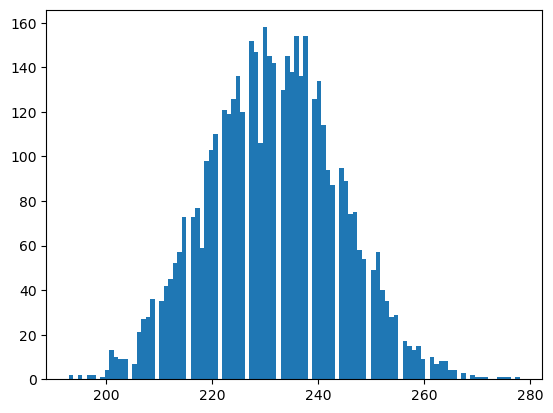

In [ ]:
from matplotlib import pyplot as plt

plt.hist(drug_y_all.sum(axis = 0), bins = 100)
plt.show()

In [16]:
drug_y_all.sum(axis = 0)/drug_y_all.shape[0]


BRD-A00077618-236-07-6::2.5::HTS               0.264069
BRD-A00100033-001-08-9::2.5::HTS               0.239177
BRD-A00147595-001-01-5::2.5::HTS               0.240260
BRD-A00218260-001-03-4::2.5::HTS               0.264069
BRD-A00376169-001-01-6::2.5::HTS               0.252165
                                                 ...   
BRD-K99506538-001-03-8::2.5::MTS004            0.256494
BRD-K99616396-001-05-1::2.499991421::MTS004    0.241342
BRD-K99879819-001-02-1::2.5187366::MTS004      0.275974
BRD-K99919177-001-01-3::2.5::MTS004            0.257576
BRD-M63173034-001-03-6::2.64076472::MTS004     0.275974
Length: 4686, dtype: float64

In [ ]:
model_map = {}
for d in drug_list[0:10]:
	model_map[d] = skl_drug_model(dataset_druggable_X, drug_y_druggable, d, 
		model = SGDClassifier, 
		oversample = True, 
		fixed_params={'loss':'modified_huber', 'penalty':'elasticnet', 'learning_rate':'optimal'},
		search_params=GRID_SEARCH_PARAM['SGD'],
		outdir='druggable_output'
		)

{'alpha': 0.02, 'l1_ratio': 0.1}
{'alpha': 0.02, 'l1_ratio': 0.15}
{'alpha': 0.02, 'l1_ratio': 0.15}
{'alpha': 0.02, 'l1_ratio': 0.05}
{'alpha': 0.02, 'l1_ratio': 0.15}
{'alpha': 0.05, 'l1_ratio': 0.05}
{'alpha': 0.02, 'l1_ratio': 0.05}
{'alpha': 0.05, 'l1_ratio': 0.05}
{'alpha': 0.05, 'l1_ratio': 0.1}
{'alpha': 0.02, 'l1_ratio': 0.1}


In [ ]:
plt.hist(drug_y_all.sum(axis = 0), bins = 100)
plt.show()

In [ ]:
model_map = {}
for d in drug_list[0:1]:
	model_map[d] = skl_drug_model(drug_X, drug_y_all, d, 
		model = XGBClassifier, 
		oversample = True, 
		fixed_params={'loss':'modified_huber', 'penalty':'elasticnet', 'learning_rate':'optimal'},
		search_params=GRID_SEARCH_PARAM['SGD'],
		)

In [111]:
write_drug_model_result(model_map['BRD-A00077618-236-07-6::2.5::HTS'], out_dir = 'output')

In [99]:
model_map['BRD-A00077618-236-07-6::2.5::HTS']['cv_results']

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,1.901527,0.085997,0.810811,0.709677,0.536585,0.611111,0.820834
1,2.030090,0.086776,0.783784,0.736842,0.341463,0.466667,0.815819
2,1.912673,0.083827,0.804054,0.642857,0.658537,0.650602,0.878277
3,1.828101,0.085851,0.783784,0.714286,0.365854,0.483871,0.831776
4,1.952184,0.085737,0.802721,0.730769,0.463415,0.567164,0.788541


In [ ]:
def xgbc(drug, oversample = True):
	y = drug_y_all[drug]

	

	
	# split X and y into training and testing sets
	X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)


	if oversample:
		ros = RandomOverSampler(random_state=72)
		X_res, y_res = ros.fit_resample(X_train, y_train)
		oversample = 'oversample'
	else:
		X_res, y_res = X_train, y_train
		oversample = ''

	# declare parameters
	parameters = {
	    "n_estimators": 150,
	    "eta" : 0.1,
	    "gamma" : 0.0,
	    "max_depth" : 100,
	    "eval_metric": "auc"
	    }

	
	grid_search_parameters = {
	    "n_estimators": [100, 150, 250],
	    "eta" : [0.1],
	    "gamma" : [0.0],
	    "max_depth" : [20, 50, 100, 200],
	    }

	# instantiate the classifier
	xgb0 = XGBClassifier(**parameters, use_label_encoder=False, n_jobs=10)

	# fit the classifier to the training data
	xgb0.fit(X_res, y_res)

	# save the trained model
	joblib.dump(xgb0, "output/"+oversample+"/XGBoost_%s.joblib" % drug)

    # make predictions on test data
	y_pred = xgb0.predict(X_test)

	print(drug,
	    "XGBoost_model_parameters", xgb0, "\n",
	    "confusion_matrix:", "\n", confusion_matrix(y_test, y_pred), "\n",
	    file=open("output/"+oversample+"/confusion_matrix.txt", "a"))

	model_report = classification_report(y_test, y_pred, output_dict=True, labels=np.unique(y_pred))
	model_report = pd.DataFrame(model_report).transpose()
    
	if (model_report.index == "1").any() == True:
		r1 = pd.DataFrame(model_report.loc["1"]).transpose()
		r1.to_csv("output/"+oversample+"/classification_report_%s.csv" % drug)
	else:
		print(drug, "Nothing predicted as 1",
			file=open("output/"+oversample+"/classification_report_log.txt", "a"))

    # k-fold cross validation using multiple metric evaluation
	kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
	#cv_results = cross_validate(xgbc, X_train, y_train, cv=kfold, scoring= ['accuracy', 'precision', 'recall', 'f1'], n_jobs = 10)
	if oversample:
		imba_pipeline = Pipeline([('sampling', SMOTE(random_state=72)), 
						('classifier', XGBClassifier( n_jobs=10))])
		grid_search_parameters = {'classifier__' + key: grid_search_parameters[key] for key in grid_search_parameters}
	else:
		imba_pipeline = XGBClassifier( n_jobs=10)
	#cross_val_score(imba_pipeline, X_train, y_train, scoring='recall', cv=kf)
	grid_imba = GridSearchCV(imba_pipeline, param_grid=grid_search_parameters, cv=kfold, scoring='f1',
				    return_train_score=True)
	grid_imba.fit(X_train, y_train) 
	
	cv_results = cross_validate(imba_pipeline, X_train, y_train, cv=kfold, scoring= ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], n_jobs = 10)
	cv_results = pd.DataFrame(cv_results)
	cv_results.to_csv("output/"+oversample+"/cv_results_%s.csv" % drug)

	# feature importance with XGBoost
	fi = pd.DataFrame({'feature': list(X_train.columns),
			'importances': xgb0.feature_importances_ * 100}).\
			 sort_values('importances', ascending = False)
	fi.to_csv("output/"+oversample+"/feature_importance_%s.csv" % drug)
	return grid_imba

In [24]:
starttime = time.time()
grid_search = skl_drug_model('BRD-A00100033-001-08-9::2.5::HTS',   oversample = True, model = RandomForestClassifier
)
endtime = time.time()

{'max_depth': 200, 'n_estimators': 100}


In [ ]:
test_pipeline = make_pipeline(SMOTE(random_state=72), 
							  XGBClassifier( n_jobs=10))

{'classifier__eta': 0.1,
 'classifier__gamma': 0.0,
 'classifier__max_depth': 20,
 'classifier__n_estimators': 200}

In [26]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__max_depth,param_classifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,2.407903,0.122744,0.097765,0.001041,20,100,"{'classifier__max_depth': 20, 'classifier__n_e...",0.105263,0.195122,0.100000,...,0.143235,0.035870,2,1.0,1.0,1.0,1.0,1.0,1.0,0.0
1,2.545385,0.122996,0.095929,0.001947,20,150,"{'classifier__max_depth': 20, 'classifier__n_e...",0.054054,0.153846,0.054054,...,0.105591,0.045569,9,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2,2.892655,0.129529,0.107957,0.000965,20,250,"{'classifier__max_depth': 20, 'classifier__n_e...",0.105263,0.153846,0.054054,...,0.135237,0.051446,3,1.0,1.0,1.0,1.0,1.0,1.0,0.0
3,2.389472,0.110781,0.094437,0.000849,50,100,"{'classifier__max_depth': 50, 'classifier__n_e...",0.054054,0.105263,0.105263,...,0.116074,0.038931,5,1.0,1.0,1.0,1.0,1.0,1.0,0.0
4,2.547645,0.132144,0.094722,0.000840,50,150,"{'classifier__max_depth': 50, 'classifier__n_e...",0.153846,0.200000,0.153846,...,0.134271,0.048923,4,1.0,1.0,1.0,1.0,1.0,1.0,0.0
5,2.929747,0.106983,0.110950,0.006231,50,250,"{'classifier__max_depth': 50, 'classifier__n_e...",0.105263,0.105263,0.102564,...,0.115819,0.021111,6,1.0,1.0,1.0,1.0,1.0,1.0,0.0
6,2.443891,0.113283,0.093222,0.000679,100,100,"{'classifier__max_depth': 100, 'classifier__n_...",0.105263,0.054054,0.105263,...,0.095590,0.020797,10,1.0,1.0,1.0,1.0,1.0,1.0,0.0
7,2.496538,0.037856,0.094114,0.002203,100,150,"{'classifier__max_depth': 100, 'classifier__n_...",0.105263,0.153846,0.105263,...,0.115565,0.037605,7,1.0,1.0,1.0,1.0,1.0,1.0,0.0
8,2.890069,0.040819,0.106934,0.000959,100,250,"{'classifier__max_depth': 100, 'classifier__n_...",0.054054,0.105263,0.054054,...,0.064296,0.039854,12,1.0,1.0,1.0,1.0,1.0,1.0,0.0
9,2.352509,0.097195,0.095394,0.002218,200,100,"{'classifier__max_depth': 200, 'classifier__n_...",0.105263,0.153846,0.105263,...,0.145479,0.037461,1,1.0,1.0,1.0,1.0,1.0,1.0,0.0


In [50]:
starttime = time.time()
xgbc('BRD-A00100033-001-08-9::2.5::HTS'
)
endtime = time.time()

/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:37:34] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1745056857893/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/users/ysu13/miniforge3/envs/drug_sen